# **Telecom X Parte II**

**Misión**

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.



**Objetivos del Desafío**

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

## **Preparación de los Datos**

### **Extracción del Archivo Tratado**

Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/datos_tratados.csv')
df.head(5)

,customerID,Churn,género,adulto_mayor,tiene_pareja,tiene_dependientes,antigüedad_meses,servicio_telefonía,múltiples_líneas,servicio_internet,...,streaming_tv,streaming_películas,tipo_contrato,facturación_sin_papel,método_pago,cargo_mensual,cargo_total,cuentas_diarias,churn_bin,churn_label
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,1,0,Anual,1,Cheque enviado,65.6,593.30,2.186667,0,No evade (churn=No)
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,1,Mensual,0,Cheque enviado,59.9,542.40,1.996667,0,No evade (churn=No)
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fibra óptica,...,0,0,Mensual,1,Cheque electrónico,73.9,280.85,2.463333,1,Evade (churn=Yes)
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fibra óptica,...,1,1,Mensual,1,Cheque electrónico,98.0,1237.85,3.266667,1,Evade (churn=Yes)
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fibra óptica,...,1,0,Mensual,1,Cheque enviado,83.9,267.40,2.796667,1,Evade (churn=Yes)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customerID              7043 non-null   object 
 1   Churn                   7043 non-null   object 
 2   género                  7043 non-null   object 
 3   adulto_mayor            7043 non-null   int64  
 4   tiene_pareja            7043 non-null   int64  
 5   tiene_dependientes      7043 non-null   int64  
 6   antigüedad_meses        7043 non-null   int64  
 7   servicio_telefonía      7043 non-null   int64  
 8   múltiples_líneas        7043 non-null   int64  
 9   servicio_internet       7043 non-null   object 
 10  seguridad_online        7043 non-null   int64  
 11  respaldo_online         7043 non-null   int64  
 12  protección_dispositivo  7043 non-null   int64  
 13  soporte_técnico         7043 non-null   int64  
 14  streaming_tv            7043 non-null   

### **Eliminación de Columnas Irrelevantes**

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [5]:
df.columns.tolist()

['customerID',
 'Churn',
 'género',
 'adulto_mayor',
 'tiene_pareja',
 'tiene_dependientes',
 'antigüedad_meses',
 'servicio_telefonía',
 'múltiples_líneas',
 'servicio_internet',
 'seguridad_online',
 'respaldo_online',
 'protección_dispositivo',
 'soporte_técnico',
 'streaming_tv',
 'streaming_películas',
 'tipo_contrato',
 'facturación_sin_papel',
 'método_pago',
 'cargo_mensual',
 'cargo_total',
 'cuentas_diarias',
 'churn_bin',
 'churn_label']

In [6]:
df_modelo = df.copy()

In [7]:
columnas_irrelevantes = ['customerID']

In [8]:
columnas_a_eliminar = [col for col in columnas_irrelevantes if col in df_modelo.columns]

df_modelo.drop(columns=columnas_a_eliminar, inplace=True)

print("Columnas eliminadas:", columnas_a_eliminar)
print("Dimensiones del dataframe después de eliminar columnas irrelevantes:", df_modelo.shape)
df_modelo.head()

Columnas eliminadas: ['customerID']
Dimensiones del dataframe después de eliminar columnas irrelevantes: (7043, 23)


,Churn,género,adulto_mayor,tiene_pareja,tiene_dependientes,antigüedad_meses,servicio_telefonía,múltiples_líneas,servicio_internet,seguridad_online,...,streaming_tv,streaming_películas,tipo_contrato,facturación_sin_papel,método_pago,cargo_mensual,cargo_total,cuentas_diarias,churn_bin,churn_label
0,No,Female,0,1,1,9,1,0,DSL,0,...,1,0,Anual,1,Cheque enviado,65.6,593.30,2.186667,0,No evade (churn=No)
1,No,Male,0,0,0,9,1,1,DSL,0,...,0,1,Mensual,0,Cheque enviado,59.9,542.40,1.996667,0,No evade (churn=No)
2,Yes,Male,0,0,0,4,1,0,Fibra óptica,0,...,0,0,Mensual,1,Cheque electrónico,73.9,280.85,2.463333,1,Evade (churn=Yes)
3,Yes,Male,1,1,0,13,1,0,Fibra óptica,0,...,1,1,Mensual,1,Cheque electrónico,98.0,1237.85,3.266667,1,Evade (churn=Yes)
4,Yes,Female,1,1,0,3,1,0,Fibra óptica,0,...,1,0,Mensual,1,Cheque enviado,83.9,267.40,2.796667,1,Evade (churn=Yes)


In [9]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Churn                   7043 non-null   object 
 1   género                  7043 non-null   object 
 2   adulto_mayor            7043 non-null   int64  
 3   tiene_pareja            7043 non-null   int64  
 4   tiene_dependientes      7043 non-null   int64  
 5   antigüedad_meses        7043 non-null   int64  
 6   servicio_telefonía      7043 non-null   int64  
 7   múltiples_líneas        7043 non-null   int64  
 8   servicio_internet       7043 non-null   object 
 9   seguridad_online        7043 non-null   int64  
 10  respaldo_online         7043 non-null   int64  
 11  protección_dispositivo  7043 non-null   int64  
 12  soporte_técnico         7043 non-null   int64  
 13  streaming_tv            7043 non-null   int64  
 14  streaming_películas     7043 non-null   

### **Encoding**

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder

In [13]:
# Revisar variable objetivo antes del encoding
df_modelo['Churn'].value_counts(dropna=False)

,count
Churn,
0,5174
1,1869


In [14]:
# Estandarizar la variable objetivo a formato binario
df_modelo['Churn'] = df_modelo['Churn'].replace({
    'Yes': 1, 'No': 0,
    'Sí': 1, 'No ': 0
})

print(df_modelo['Churn'].value_counts(dropna=False))

Churn
0    5174
1    1869
Name: count, dtype: int64


In [15]:
# Separar variables predictoras y variable objetivo
X = df_modelo.drop(columns='Churn')
y = df_modelo['Churn']

In [57]:
# Aplicar one-hot encoding una sola vez
X_encoded = pd.get_dummies(X, drop_first=True)

# Convertir booleanos a 0 y 1
X_encoded = X_encoded.astype(int)

print("Dimensiones de X antes del encoding:", X.shape)
print("Dimensiones de X después del encoding:", X_encoded.shape)

X_encoded.head()

Dimensiones de X antes del encoding: (7043, 22)
Dimensiones de X después del encoding: (7043, 26)


,adulto_mayor,tiene_pareja,tiene_dependientes,antigüedad_meses,servicio_telefonía,múltiples_líneas,seguridad_online,respaldo_online,protección_dispositivo,soporte_técnico,...,churn_bin,género_Male,servicio_internet_Fibra óptica,servicio_internet_Sin servicio,tipo_contrato_Bianual,tipo_contrato_Mensual,método_pago_Cheque enviado,método_pago_Tarjeta automática,método_pago_Transferencia automática,churn_label_No evade (churn=No)
0,0,1,1,9,1,0,0,1,0,1,...,0,0,0,0,0,0,1,0,0,1
1,0,0,0,9,1,1,0,0,0,0,...,0,1,0,0,0,1,1,0,0,1
2,0,0,0,4,1,0,0,0,1,0,...,1,1,1,0,0,1,0,0,0,0
3,1,1,0,13,1,0,0,1,1,0,...,1,1,1,0,0,1,0,0,0,0
4,1,1,0,3,1,0,0,0,0,1,...,1,0,1,0,0,1,1,0,0,0


#### Eliminación de Variables Derivadas de Churn

Algunas columnas del dataset fueron creadas durante el análisis exploratorio para facilitar la interpretación de la variable objetivo.
Sin embargo, estas variables contienen información directa sobre la cancelación del cliente (churn), por lo que no deben ser utilizadas
como variables predictoras.

Si estas columnas se incluyen en el entrenamiento del modelo, se produce **data leakage**, lo que significa que el modelo tendría acceso
a información que en la práctica no estaría disponible al momento de hacer predicciones.

Por esta razón, eliminaremos todas las columnas derivadas de churn antes de continuar con el modelado.

In [58]:
columnas_churn_derivadas = [col for col in X_encoded.columns if col.lower().startswith('churn')]

X_encoded = X_encoded.drop(columns=columnas_churn_derivadas, errors='ignore')

print("Columnas eliminadas:", columnas_churn_derivadas)
print("Dimensiones de X después de eliminar variables derivadas de churn:", X_encoded.shape)

X_encoded.head()

Columnas eliminadas: ['churn_bin', 'churn_label_No evade (churn=No)']
Dimensiones de X después de eliminar variables derivadas de churn: (7043, 24)


,adulto_mayor,tiene_pareja,tiene_dependientes,antigüedad_meses,servicio_telefonía,múltiples_líneas,seguridad_online,respaldo_online,protección_dispositivo,soporte_técnico,...,cargo_total,cuentas_diarias,género_Male,servicio_internet_Fibra óptica,servicio_internet_Sin servicio,tipo_contrato_Bianual,tipo_contrato_Mensual,método_pago_Cheque enviado,método_pago_Tarjeta automática,método_pago_Transferencia automática
0,0,1,1,9,1,0,0,1,0,1,...,593,2,0,0,0,0,0,1,0,0
1,0,0,0,9,1,1,0,0,0,0,...,542,1,1,0,0,0,1,1,0,0
2,0,0,0,4,1,0,0,0,1,0,...,280,2,1,1,0,0,1,0,0,0
3,1,1,0,13,1,0,0,1,1,0,...,1237,3,1,1,0,0,1,0,0,0
4,1,1,0,3,1,0,0,0,0,1,...,267,2,0,1,0,0,1,1,0,0


### **Verificación de la Proporción de Cancelación (Churn)**

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html

In [31]:
import matplotlib.pyplot as plt

In [30]:
proporcion_churn = y.value_counts(normalize=True).mul(100).round(2)
conteo_churn = y.value_counts()

print("Conteo de clases:")
print(conteo_churn)
print("\nProporción de clases (%):")
print(proporcion_churn)

Conteo de clases:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporción de clases (%):
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


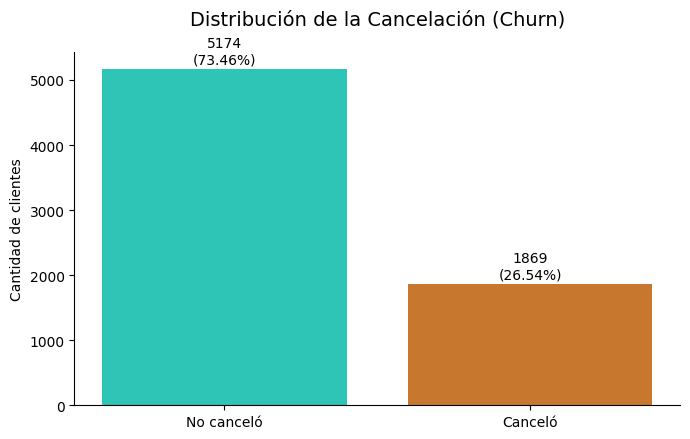

In [60]:
fig, ax = plt.subplots(figsize=(7, 4.5))

colores = ['#2EC4B6', '#C7772E']  # turquesa y naranja metálico suave

barras = ax.bar(
    ['No canceló', 'Canceló'],
    conteo_churn.values,
    color=colores
)

ax.set_title(
    'Distribución de la Cancelación (Churn)',
    loc='center',
    fontsize=14,
    pad=20
)

ax.set_ylabel('Cantidad de clientes')
ax.set_xlabel('')

for barra, valor, pct in zip(barras, conteo_churn.values, proporcion_churn.values):
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 40,
        f'{valor}\n({pct}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### **Balanceo de Clases**

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

🔎 Sugerencia:
Puedes leer más sobre cómo manejar el desbalanceo de clases en este artículo:
https://www.alura.com.br/artigos/lidando-com-desbalanceamento-dados?srsltid=AfmBOopTgyC_tpujwkC778gYjcLituqgxknih2Cr4vD72_OFHSB4v35M

### **Normalización o Estandarización**

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

🔎 Sugerencia:
Puedes leer más sobre normalización y estandarización de datos en este artículo:
https://medium.com/ipnet-growth-partner/padronizacao-normalizacao-dados-machine-learning-f8f29246c12

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [34]:
# Separación de datos antes de escalar
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4930, 24)
X_test: (2113, 24)
y_train: (4930,)
y_test: (2113,)


In [61]:
# Escalado para modelos sensibles a la magnitud de las variables
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,adulto_mayor,tiene_pareja,tiene_dependientes,antigüedad_meses,servicio_telefonía,múltiples_líneas,seguridad_online,respaldo_online,protección_dispositivo,soporte_técnico,...,cargo_total,cuentas_diarias,género_Male,servicio_internet_Fibra óptica,servicio_internet_Sin servicio,tipo_contrato_Bianual,tipo_contrato_Mensual,método_pago_Cheque enviado,método_pago_Tarjeta automática,método_pago_Transferencia automática
5609,-0.437818,-0.962175,-0.6594,-0.753333,0.314991,-0.857143,-0.632276,-0.723198,1.382747,-0.642345,...,-0.520539,0.352477,0.980315,1.114418,-0.5243,-0.564076,0.911412,-0.540618,-0.527757,-0.53623
2209,-0.437818,-0.962175,-0.6594,-1.119298,0.314991,-0.857143,-0.632276,-0.723198,1.382747,-0.642345,...,-0.857527,0.352477,0.980315,-0.897329,-0.5243,-0.564076,-1.097198,1.849736,-0.527757,-0.53623
6919,-0.437818,1.039312,-0.6594,0.100585,0.314991,1.166667,-0.632276,-0.723198,-0.723198,-0.642345,...,0.117988,0.352477,0.980315,1.114418,-0.5243,-0.564076,0.911412,-0.540618,-0.527757,-0.53623
2284,-0.437818,1.039312,-0.6594,1.035828,0.314991,1.166667,1.581588,1.382747,1.382747,-0.642345,...,1.130702,0.352477,0.980315,-0.897329,-0.5243,1.772811,-1.097198,-0.540618,-0.527757,-0.53623
845,-0.437818,-0.962175,-0.6594,-1.241286,0.314991,-0.857143,-0.632276,1.382747,-0.723198,-0.642345,...,-0.959499,-0.558274,-1.020080,-0.897329,-0.5243,-0.564076,0.911412,1.849736,-0.527757,-0.53623


## **Correlación y Selección de Variables**

### **Análisis de Correlación**

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

In [91]:
df_correlacion = X_encoded.copy()
df_correlacion['Churn'] = y

correlacion = df_correlacion.corr(numeric_only=True)
correlacion_churn = correlacion['Churn'].drop('Churn').sort_values()

top_corr = correlacion_churn.tail(10).reset_index()
top_corr.columns = ['Variable', 'Correlación']

vmin = top_corr['Correlación'].min()
vmax = top_corr['Correlación'].max()

def color_fila(row):
    valor = row['Correlación']
    rango = vmax - vmin if vmax != vmin else 1
    intensidad = (valor - vmin) / rango

    if intensidad < 0.33:
        color = '#F4E1D2'
    elif intensidad < 0.66:
        color = '#EFEFEF'
    else:
        color = '#D9F0EC'

    return [f'background-color: {color}; color: #1f1f1f;' for _ in row]

styled_corr = (
    top_corr.style
    .format({'Correlación': '{:.3f}'})
    .apply(color_fila, axis=1)
    .set_table_styles([
        {
            'selector': 'table',
            'props': [
                ('border-collapse', 'collapse'),
                ('border', '1px solid #8a8a8a'),
                ('font-size', '11pt')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#2EC4B6'),
                ('color', '#1f1f1f'),
                ('border', '1px solid #8a8a8a'),
                ('padding', '8px'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #8a8a8a'),
                ('padding', '8px')
            ]
        }
    ])
)

styled_corr

,Variable,Correlación
0,servicio_telefonía,0.012
1,múltiples_líneas,0.040
2,streaming_películas,0.061
3,streaming_tv,0.063
4,adulto_mayor,0.151
5,facturación_sin_papel,0.192
6,cargo_mensual,0.193
7,cuentas_diarias,0.196
8,servicio_internet_Fibra óptica,0.308
9,tipo_contrato_Mensual,0.405


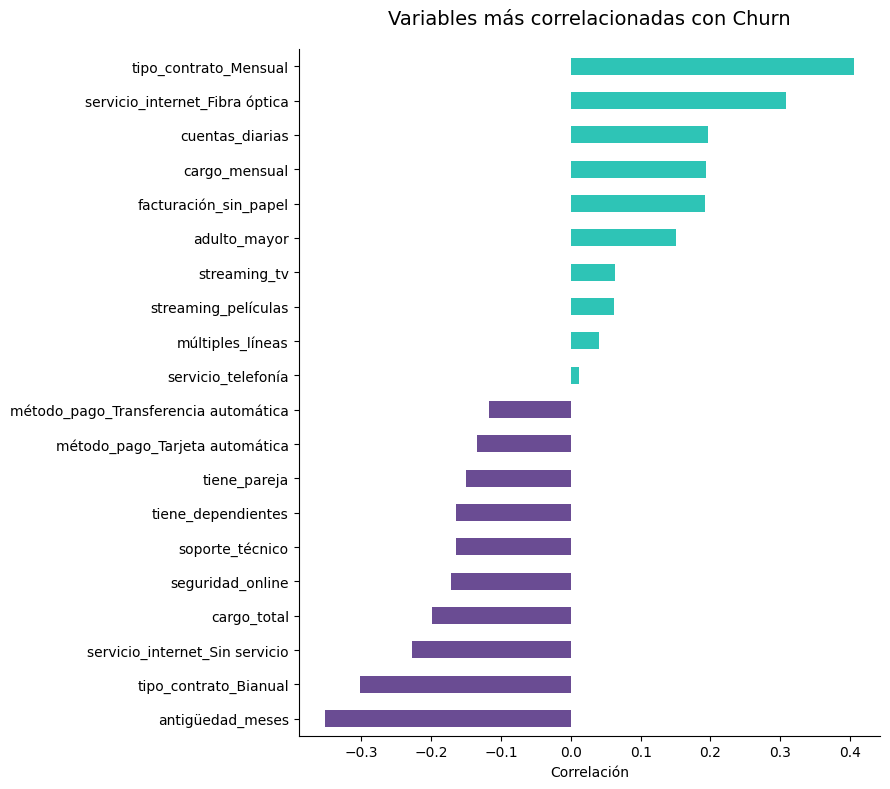

In [64]:
top_pos = correlacion_churn.tail(10)
top_neg = correlacion_churn.head(10)
correlaciones_top = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(9, 8))

colores = [
    '#6A4C93' if v < 0 else '#2EC4B6'
    for v in correlaciones_top.sort_values()
]

correlaciones_top.sort_values().plot(
    kind='barh',
    ax=ax,
    color=colores
)

ax.set_title(
    'Variables más correlacionadas con Churn',
    loc='center',
    fontsize=14,
    pad=18
)

ax.set_xlabel('Correlación')
ax.set_ylabel('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### **Análisis Dirigido**

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

- Tiempo de contrato × Cancelación

- Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

In [65]:
df_modelo.columns.tolist()

['Churn',
 'género',
 'adulto_mayor',
 'tiene_pareja',
 'tiene_dependientes',
 'antigüedad_meses',
 'servicio_telefonía',
 'múltiples_líneas',
 'servicio_internet',
 'seguridad_online',
 'respaldo_online',
 'protección_dispositivo',
 'soporte_técnico',
 'streaming_tv',
 'streaming_películas',
 'tipo_contrato',
 'facturación_sin_papel',
 'método_pago',
 'cargo_mensual',
 'cargo_total',
 'cuentas_diarias',
 'churn_bin',
 'churn_label']

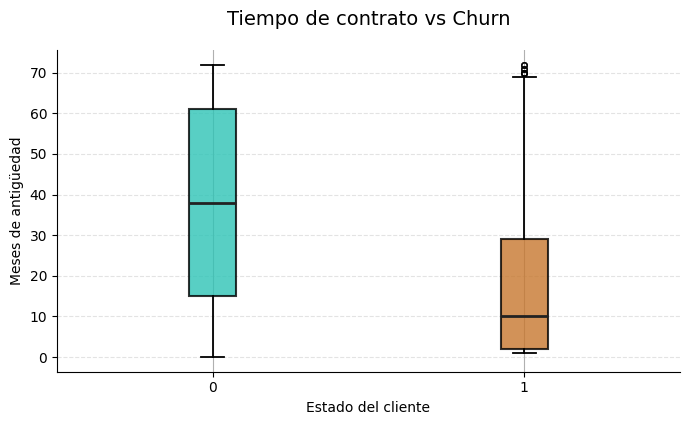

In [73]:
# Buscar automáticamente la columna de antigüedad
col_antiguedad = None
for col in ['tenure', 'antigüedad_meses', 'antiguedad_meses']:
    if col in df_modelo.columns:
        col_antiguedad = col
        break

if col_antiguedad:

    fig, ax = plt.subplots(figsize=(7, 4.5))

    box = df_modelo.boxplot(
        column=col_antiguedad,
        by='Churn',
        ax=ax,
        patch_artist=True,
        boxprops=dict(linewidth=1.5),
        medianprops=dict(color='#222222', linewidth=2),
        whiskerprops=dict(linewidth=1.3),
        capprops=dict(linewidth=1.3),
        flierprops=dict(marker='o', markersize=4, alpha=0.4)
    )

    colores = ['#2EC4B6', '#C7772E']
    for patch, color in zip(ax.patches, colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_title(
        'Tiempo de contrato vs Churn',
        fontsize=14,
        pad=18,
        loc='center'
    )

    ax.set_xlabel('Estado del cliente')
    ax.set_ylabel('Meses de antigüedad')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

else:
    print("No se encontró una columna de antigüedad para graficar.")

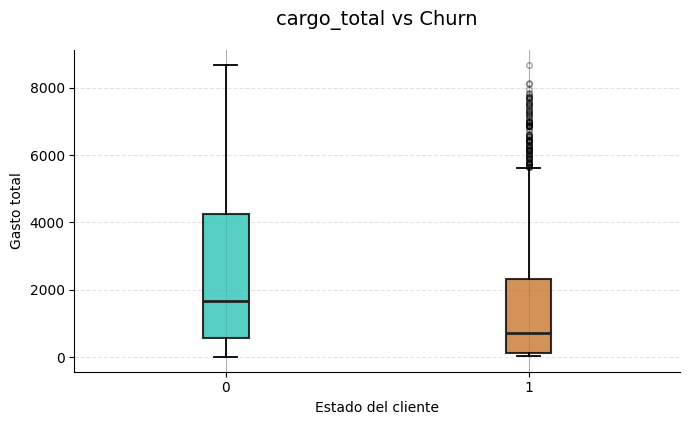

In [74]:
col_total = None
for col in ['Charges.Total', 'TotalCharges', 'total_gastado', 'cargo_total', 'gasto_total']:
    if col in df_modelo.columns:
        col_total = col
        break

if col_total:

    fig, ax = plt.subplots(figsize=(7, 4.5))

    box = df_modelo.boxplot(
        column=col_total,
        by='Churn',
        ax=ax,
        patch_artist=True,
        boxprops=dict(linewidth=1.5),
        medianprops=dict(color='#222222', linewidth=2),
        whiskerprops=dict(linewidth=1.3),
        capprops=dict(linewidth=1.3),
        flierprops=dict(marker='o', markersize=4, alpha=0.35)
    )

    colores = ['#2EC4B6', '#C7772E']
    for patch, color in zip(ax.patches, colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_title(
        f'{col_total} vs Churn',
        fontsize=14,
        loc='center',
        pad=18
    )

    ax.set_xlabel('Estado del cliente')
    ax.set_ylabel('Gasto total')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

else:
    print("No se encontró una columna de gasto total para graficar.")

In [95]:
if col_antiguedad:
    tabla_antiguedad = df_modelo.groupby('Churn')[col_antiguedad].describe().round(2)

    display(
        tabla_antiguedad.style
        .format('{:.2f}')
        .set_table_styles([
            {'selector': 'table',
             'props': [('border-collapse', 'collapse'),
                       ('font-size', '10.5pt'),
                       ('width', '850px')]},

            {'selector': 'th',
             'props': [('background-color', '#2EC4B6'),
                       ('color', '#1f1f1f'),
                       ('border', '1px solid #999'),
                       ('padding', '8px'),
                       ('width', '90px')]},

            {'selector': 'td',
             'props': [('border', '1px solid #c0c0c0'),
                       ('padding', '8px'),
                       ('text-align', 'center'),
                       ('background-color', '#fafafa'),
                       ('color', '#1f1f1f'),
                       ('width', '90px')]},

            {'selector': 'tbody tr:nth-child(even) td',
             'props': [('background-color', '#f1f1f1')]}
        ])
    )


if col_total:
    tabla_total = df_modelo.groupby('Churn')[col_total].describe().round(2)

    display(
        tabla_total.style
        .format('{:.2f}')
        .set_table_styles([
            {'selector': 'table',
             'props': [('border-collapse', 'collapse'),
                       ('font-size', '10.5pt'),
                       ('width', '850px')]},

            {'selector': 'th',
             'props': [('background-color', '#2EC4B6'),
                       ('color', '#1f1f1f'),
                       ('border', '1px solid #999'),
                       ('padding', '8px'),
                       ('width', '90px')]},

            {'selector': 'td',
             'props': [('border', '1px solid #c0c0c0'),
                       ('padding', '8px'),
                       ('text-align', 'center'),
                       ('background-color', '#fafafa'),
                       ('color', '#1f1f1f'),
                       ('width', '90px')]},

            {'selector': 'tbody tr:nth-child(even) td',
             'props': [('background-color', '#f1f1f1')]}
        ])
    )

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.00,37.57,24.11,0.00,15.00,38.00,61.00,72.00
1,1869.00,17.98,19.53,1.00,2.00,10.00,29.00,72.00


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.00,2549.91,2329.95,0.00,572.90,1679.52,4262.85,8672.45
1,1869.00,1531.80,1890.82,18.85,134.50,703.55,2331.30,8684.80


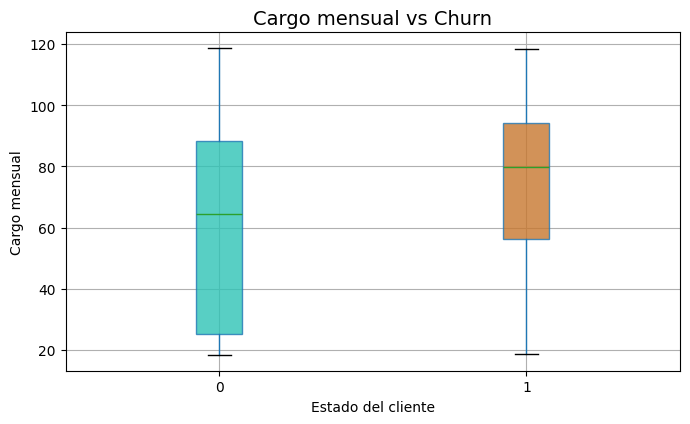

In [105]:
col_mensual = None
for col in ['Charges.Monthly','MonthlyCharges','cargo_mensual']:
    if col in df_modelo.columns:
        col_mensual = col
        break

if col_mensual:

    fig, ax = plt.subplots(figsize=(7,4.5))

    df_modelo.boxplot(
        column=col_mensual,
        by='Churn',
        ax=ax,
        patch_artist=True
    )

    colores = ['#2EC4B6','#C7772E']

    for patch,color in zip(ax.patches,colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_title('Cargo mensual vs Churn', fontsize=14)
    ax.set_xlabel('Estado del cliente')
    ax.set_ylabel('Cargo mensual')

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

## **Modelado Predictivo**

### **Separación de Datos**

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [76]:
print("Proporción de churn en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

print("\nProporción de churn en prueba:")
print(y_test.value_counts(normalize=True).round(3))

Proporción de churn en entrenamiento:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Proporción de churn en prueba:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


### **Creación de Modelos**

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

- Un modelo puede requerir normalización, como Regresión Logística o KNN.

- El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

- Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

- Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [43]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [44]:
# Modelo baseline
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

In [45]:
# Regresión Logística con datos escalados
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

In [46]:
# Random Forest sin escalado
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

### **Evaluación de los Modelos**

Evalúa cada modelo utilizando las siguientes métricas:

- Exactitud (Acurácia)

- Precisión

- Recall

- F1-score

- Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

- ¿Cuál modelo tuvo el mejor desempeño?

- ¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

  - Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

  - Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [78]:
def evaluar_modelo(nombre, y_real, y_pred):
    print(f'===== {nombre} =====')
    print('Accuracy :', round(accuracy_score(y_real, y_pred), 4))
    print('Precision:', round(precision_score(y_real, y_pred, zero_division=0), 4))
    print('Recall   :', round(recall_score(y_real, y_pred, zero_division=0), 4))
    print('F1-score :', round(f1_score(y_real, y_pred, zero_division=0), 4))
    print('\nClassification Report:')
    print(classification_report(y_real, y_pred, zero_division=0))

In [79]:
evaluar_modelo('Dummy Classifier', y_test, y_pred_dummy)
evaluar_modelo('Regresión Logística', y_test, y_pred_log)
evaluar_modelo('Random Forest', y_test, y_pred_rf)

===== Dummy Classifier =====
Accuracy : 0.7345
Precision: 0.0
Recall   : 0.0
F1-score : 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1552
           1       0.00      0.00      0.00       561

    accuracy                           0.73      2113
   macro avg       0.37      0.50      0.42      2113
weighted avg       0.54      0.73      0.62      2113

===== Regresión Logística =====
Accuracy : 0.7974
Precision: 0.6394
Recall   : 0.5437
F1-score : 0.5877

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113

===== Random Forest =====
Accuracy : 0.7875
Precision: 0.6261
Recall   : 0.4955
F1-score : 0.5532

Cla

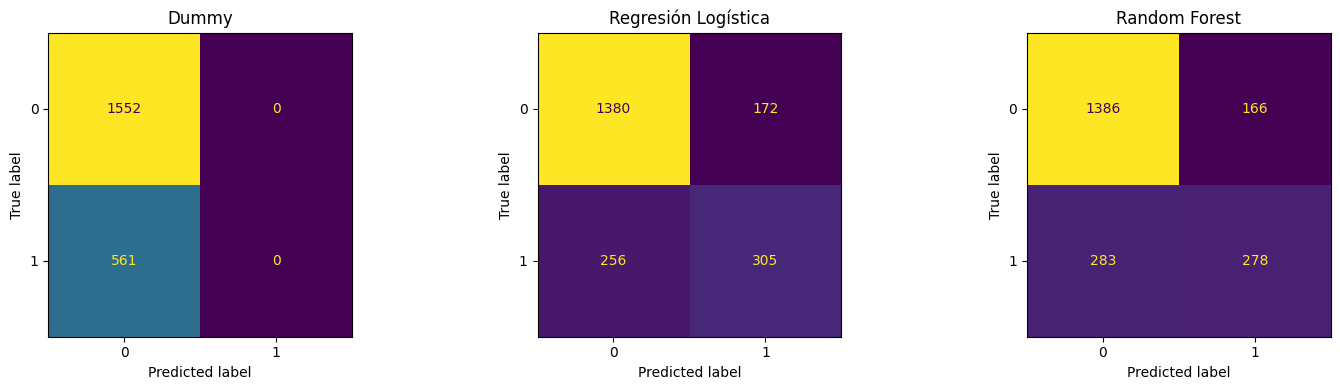

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pred, titulo in zip(
    axes,
    [y_pred_dummy, y_pred_log, y_pred_rf],
    ['Dummy', 'Regresión Logística', 'Random Forest']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

In [81]:
def score_entrenamiento_prueba(modelo, X_tr, y_tr, X_te, y_te, nombre):
    score_train = modelo.score(X_tr, y_tr)
    score_test = modelo.score(X_te, y_te)

    print(f'--- {nombre} ---')
    print('Score entrenamiento:', round(score_train, 4))
    print('Score prueba       :', round(score_test, 4))
    print('Diferencia         :', round(score_train - score_test, 4))

In [82]:
score_entrenamiento_prueba(dummy, X_train, y_train, X_test, y_test, 'Dummy')
score_entrenamiento_prueba(log_reg, X_train_scaled, y_train, X_test_scaled, y_test, 'Regresión Logística')
score_entrenamiento_prueba(rf, X_train, y_train, X_test, y_test, 'Random Forest')

--- Dummy ---
Score entrenamiento: 0.7347
Score prueba       : 0.7345
Diferencia         : 0.0002
--- Regresión Logística ---
Score entrenamiento: 0.8095
Score prueba       : 0.7974
Diferencia         : 0.0121
--- Random Forest ---
Score entrenamiento: 0.9907
Score prueba       : 0.7875
Diferencia         : 0.2032


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## **Interpretación y Conclusiones**

### **Análisis de la Importancia de las Variables**

Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

- Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

- KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

- Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

- SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

- Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

In [97]:
coeficientes = pd.DataFrame({
    'Variable': X_train_scaled.columns,
    'Coeficiente': log_reg.coef_[0]
})

coeficientes['Impacto_absoluto'] = coeficientes['Coeficiente'].abs()
coeficientes = coeficientes.sort_values('Impacto_absoluto', ascending=False)

display(
    coeficientes.head(10).style
    .format({'Coeficiente': '{:.3f}', 'Impacto_absoluto': '{:.3f}'})
    .set_table_styles([
        {'selector': 'table',
         'props': [('border-collapse','collapse'),
                   ('font-size','10.5pt'),
                   ('width','650px'),
                   ('background-color','#ffffff')]},

        {'selector': 'th',
         'props': [('background-color','#2EC4B6'),
                   ('color','#111111'),
                   ('border','1px solid #999'),
                   ('padding','8px'),
                   ('font-weight','bold')]},

        {'selector': 'td',
         'props': [('border','1px solid #c0c0c0'),
                   ('padding','8px'),
                   ('text-align','center'),
                   ('background-color','#ffffff'),
                   ('color','#111111')]},

        {'selector': 'tbody tr:nth-child(even) td',
         'props': [('background-color','#f2f2f2'),
                   ('color','#111111')]}
    ])
)

,Variable,Coeficiente,Impacto_absoluto
3,antigüedad_meses,-1.481,1.481
14,cargo_total,0.732,0.732
17,servicio_internet_Fibra óptica,0.504,0.504
18,servicio_internet_Sin servicio,-0.444,0.444
20,tipo_contrato_Mensual,0.368,0.368
19,tipo_contrato_Bianual,-0.255,0.255
13,cargo_mensual,-0.230,0.230
12,facturación_sin_papel,0.202,0.202
22,método_pago_Tarjeta automática,-0.179,0.179
9,soporte_técnico,-0.169,0.169


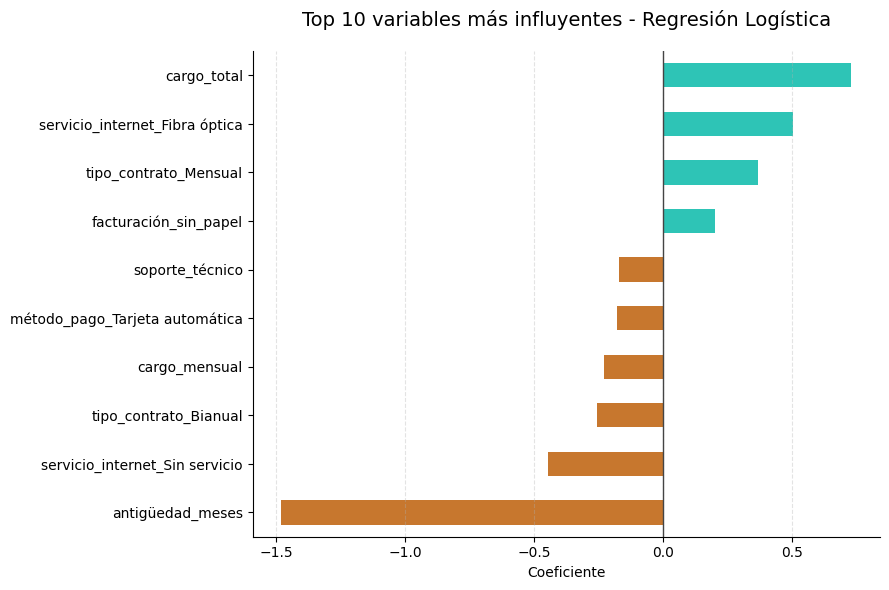

In [85]:
fig, ax = plt.subplots(figsize=(9, 6))

datos = coeficientes.head(10).sort_values('Coeficiente')

colores = ['#2EC4B6' if v > 0 else '#C7772E' for v in datos['Coeficiente']]

datos.plot(
    x='Variable',
    y='Coeficiente',
    kind='barh',
    legend=False,
    ax=ax,
    color=colores
)

ax.set_title(
    'Top 10 variables más influyentes - Regresión Logística',
    loc='center',
    fontsize=14,
    pad=18
)

ax.set_xlabel('Coeficiente')
ax.set_ylabel('')
ax.axvline(0, color='#444444', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

In [89]:
importancias_rf = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

top_importancias = importancias_rf.head(10).copy()

vmin = top_importancias['Importancia'].min()
vmax = top_importancias['Importancia'].max()

def color_fila(row):
    valor = row['Importancia']
    rango = vmax - vmin if vmax != vmin else 1
    intensidad = (valor - vmin) / rango

    if intensidad < 0.33:
        color = '#F4E1D2'
    elif intensidad < 0.66:
        color = '#EFEFEF'
    else:
        color = '#D9F0EC'

    return [f'background-color: {color}; color: #1f1f1f;' for _ in row]

styled_table = (
    top_importancias.style
    .format({'Importancia': '{:.4f}'})
    .apply(color_fila, axis=1)
    .set_table_styles([
        {
            'selector': 'table',
            'props': [
                ('border-collapse', 'collapse'),
                ('border', '1px solid #8a8a8a'),
                ('font-size', '11pt')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#2EC4B6'),
                ('color', '#1f1f1f'),
                ('border', '1px solid #8a8a8a'),
                ('padding', '8px'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #8a8a8a'),
                ('padding', '8px')
            ]
        }
    ])
)

styled_table

,Variable,Importancia
14,cargo_total,0.1877
3,antigüedad_meses,0.1732
13,cargo_mensual,0.1301
20,tipo_contrato_Mensual,0.0668
17,servicio_internet_Fibra óptica,0.0426
16,género_Male,0.0316
12,facturación_sin_papel,0.0285
1,tiene_pareja,0.0256
19,tipo_contrato_Bianual,0.0252
9,soporte_técnico,0.0243


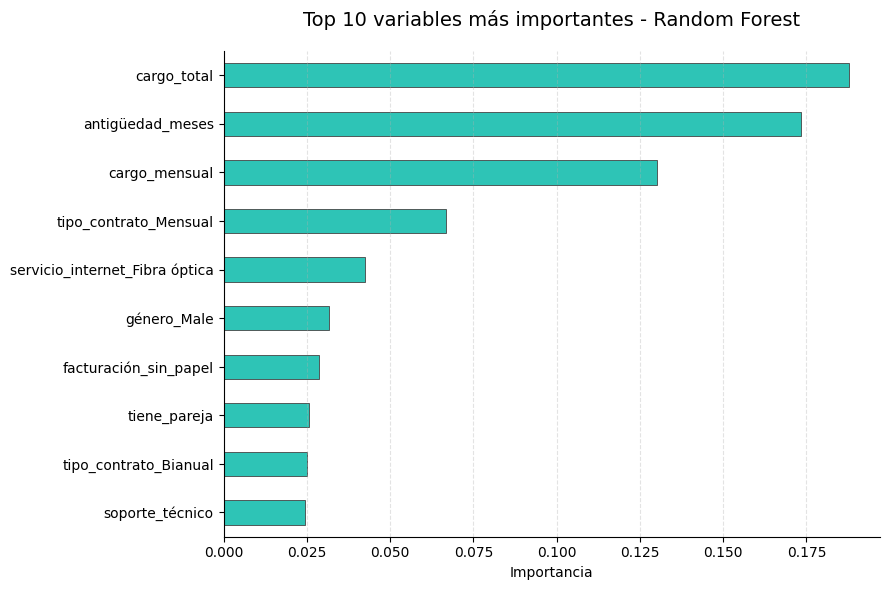

In [100]:
fig, ax = plt.subplots(figsize=(9, 6))

datos = importancias_rf.head(10).sort_values('Importancia')

colores = ['#2EC4B6'] * len(datos)

datos.plot(
    x='Variable',
    y='Importancia',
    kind='barh',
    legend=False,
    ax=ax,
    color=colores,
    edgecolor='#444444',
    linewidth=0.6
)

ax.set_title(
    'Top 10 variables más importantes - Random Forest',
    loc='center',
    fontsize=14,
    pad=18
)

ax.set_xlabel('Importancia')
ax.set_ylabel('')

ax.grid(axis='x', linestyle='--', alpha=0.35)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### **Conclusión**

Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.

In [103]:
display(
    resumen_modelos.style
    .format({'Accuracy':'{:.3f}','Precision':'{:.3f}','Recall':'{:.3f}','F1-score':'{:.3f}'})
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-score'], color='#D9F0EC')
    .set_table_styles([
        {'selector':'table','props':[('border-collapse','collapse'),('font-size','10.5pt'),('width','650px'),('background-color','#ffffff')]},
        {'selector':'th','props':[('background-color','#2EC4B6'),('color','#111111'),('border','1px solid #999'),('padding','8px')]},
        {'selector':'td','props':[('border','1px solid #c0c0c0'),('padding','8px'),('text-align','center'),('background-color','#ffffff'),('color','#111111')]},
        {'selector':'tbody tr:nth-child(even) td','props':[('background-color','#f2f2f2')]}
    ])
)

,Modelo,Accuracy,Precision,Recall,F1-score
1,Regresión Logística,0.797,0.639,0.544,0.588
2,Random Forest,0.788,0.626,0.496,0.553
0,Dummy,0.735,0.000,0.000,0.000


In [102]:
mejor_modelo = resumen_modelos.iloc[0, 0]
print(f'Mejor modelo según F1-score: {mejor_modelo}')

Mejor modelo según F1-score: Regresión Logística


In [107]:
from IPython.display import Markdown, display

display(Markdown("""

# Informe Final — Análisis Predictivo de Cancelación de Clientes

## Desempeño de los Modelos

Para abordar el problema de cancelación de clientes (churn), se entrenaron tres modelos de clasificación:

- Dummy Classifier (modelo base)
- Regresión Logística
- Random Forest

El Dummy Classifier se utilizó como línea base, ya que simplemente predice la clase mayoritaria sin aprender patrones de los datos.

Los resultados comparativos se resumen en la tabla final de métricas generada en el notebook (`resumen_modelos`).

El modelo con mejor desempeño fue **Regresión Logística**, con un **F1-score cercano a 0.59**, seguido por **Random Forest con aproximadamente 0.55**.

El uso del **F1-score** como métrica principal es adecuado para este problema, ya que equilibra **precision y recall**, lo cual es importante cuando el objetivo es detectar clientes con riesgo de cancelar.

Las matrices de confusión mostradas anteriormente permiten visualizar cómo cada modelo clasifica correctamente o confunde los casos de cancelación.

En términos generales:

- **Accuracy cercana al 80%** indica que el modelo clasifica correctamente la mayoría de los clientes.
- **Precision cercana al 0.63** indica que una proporción relevante de los clientes identificados como en riesgo realmente cancelan.
- **Recall cercano al 0.54** muestra que el modelo logra identificar aproximadamente la mitad de los clientes que cancelarán.

Esto demuestra que los modelos capturan patrones significativos en los datos y pueden utilizarse como una herramienta inicial para anticipar el churn.

---

# Factores Clave Asociados a la Cancelación

El análisis exploratorio y la interpretación de los modelos permitieron identificar los factores que más influyen en la cancelación de clientes.

Este análisis se apoyó en diversas visualizaciones generadas en el notebook, incluyendo:

- gráfico de **distribución de churn**
- **matriz de correlación con churn**
- **boxplots de antigüedad, gasto total y cargo mensual**
- **importancia de variables en Regresión Logística**
- **importancia de variables en Random Forest**

A partir de estos análisis se identificaron los siguientes factores relevantes.

---

## Antigüedad del Cliente

El boxplot **Tiempo de contrato vs Churn** muestra que los clientes con menor antigüedad presentan una mayor probabilidad de cancelar el servicio.

Las tablas descriptivas generadas para esta variable también evidencian que los clientes que cancelan tienden a tener menos meses de permanencia en la empresa.

Esto indica que **los primeros meses de relación con el cliente son una etapa crítica para su fidelización**.

---

## Tipo de Contrato

Las variables asociadas al tipo de contrato aparecen entre las más influyentes en el modelo.

Los clientes con **contratos mensuales** presentan una mayor probabilidad de cancelar en comparación con aquellos con contratos anuales o bianuales.

Esto sugiere que los contratos de mayor duración generan un mayor compromiso con el servicio.

---

## Cargo Mensual

El gráfico **Cargo mensual vs Churn** muestra que los clientes con cargos mensuales más elevados presentan una mayor tendencia a cancelar.

Esto puede estar asociado a una percepción de menor relación costo-beneficio o a la existencia de alternativas más económicas en el mercado.

---

## Uso de Servicios Adicionales

Algunas variables relacionadas con servicios complementarios (como soporte técnico, seguridad online o respaldo) aparecen entre las variables importantes del modelo.

Los clientes que utilizan más servicios adicionales tienden a permanecer más tiempo en la compañía, lo que sugiere que **una mayor integración con el ecosistema del servicio reduce la probabilidad de abandono**.

---

# Interpretación de la Importancia de Variables

La importancia de variables fue analizada mediante dos enfoques:

### Regresión Logística

Los coeficientes del modelo permiten observar qué variables incrementan o reducen la probabilidad de cancelación.

El gráfico **Top 10 variables más influyentes — Regresión Logística** muestra qué variables tienen mayor impacto positivo o negativo sobre la probabilidad de churn.

---

### Random Forest

El modelo Random Forest permite evaluar la importancia de variables a partir de la reducción de impureza en los árboles de decisión.

El gráfico **Top 10 variables más importantes — Random Forest** confirma varios de los factores detectados en el análisis exploratorio.

La coincidencia entre ambos modelos refuerza la confiabilidad de los resultados.

---

# Implicaciones Estratégicas para el Negocio

A partir del análisis realizado, es posible identificar patrones claros en el comportamiento de cancelación de clientes.

En particular, el churn está fuertemente asociado con:

- baja antigüedad del cliente
- contratos de corta duración
- cargos mensuales más elevados
- menor uso de servicios adicionales

Estos factores permiten identificar segmentos de clientes con mayor riesgo de cancelación.

---

# Estrategias de Retención Recomendadas

### Programas de retención temprana

Dado que los clientes nuevos presentan mayor riesgo de cancelación, se recomienda implementar estrategias específicas durante los primeros meses de servicio, como:

- programas de onboarding
- seguimiento de satisfacción del cliente
- incentivos iniciales de permanencia

---

### Incentivos para contratos de mayor duración

Promover contratos anuales o bianuales mediante descuentos o beneficios adicionales puede aumentar el compromiso del cliente y reducir la probabilidad de cancelación.

---

### Optimización del valor percibido del servicio

Si los cargos mensuales influyen en el churn, es importante reforzar el valor percibido del servicio mediante:

- mejoras en la calidad del servicio
- paquetes de servicios adicionales
- promociones personalizadas

---

### Promoción de servicios complementarios

Incentivar el uso de servicios adicionales puede aumentar la fidelización del cliente y fortalecer su relación con la empresa.

---

# Conclusión General

El desarrollo de modelos predictivos permitió identificar patrones relevantes asociados a la cancelación de clientes en Telecom X.

El modelo de **Regresión Logística mostró el mejor desempeño general**, manteniendo un equilibrio adecuado entre interpretabilidad y capacidad predictiva.

Más allá del rendimiento del modelo, el análisis permitió identificar variables clave que influyen en la cancelación, lo que proporciona información valiosa para diseñar estrategias de retención basadas en datos.

La implementación de acciones enfocadas en los clientes más recientes, la promoción de contratos de mayor duración y el fortalecimiento del valor percibido del servicio pueden contribuir significativamente a reducir la tasa de cancelación.

"""))



# Informe Final — Análisis Predictivo de Cancelación de Clientes

## Desempeño de los Modelos

Para abordar el problema de cancelación de clientes (churn), se entrenaron tres modelos de clasificación:

- Dummy Classifier (modelo base)
- Regresión Logística
- Random Forest

El Dummy Classifier se utilizó como línea base, ya que simplemente predice la clase mayoritaria sin aprender patrones de los datos.

Los resultados comparativos se resumen en la tabla final de métricas generada en el notebook (`resumen_modelos`).

El modelo con mejor desempeño fue **Regresión Logística**, con un **F1-score cercano a 0.59**, seguido por **Random Forest con aproximadamente 0.55**.

El uso del **F1-score** como métrica principal es adecuado para este problema, ya que equilibra **precision y recall**, lo cual es importante cuando el objetivo es detectar clientes con riesgo de cancelar.

Las matrices de confusión mostradas anteriormente permiten visualizar cómo cada modelo clasifica correctamente o confunde los casos de cancelación.

En términos generales:

- **Accuracy cercana al 80%** indica que el modelo clasifica correctamente la mayoría de los clientes.
- **Precision cercana al 0.63** indica que una proporción relevante de los clientes identificados como en riesgo realmente cancelan.
- **Recall cercano al 0.54** muestra que el modelo logra identificar aproximadamente la mitad de los clientes que cancelarán.

Esto demuestra que los modelos capturan patrones significativos en los datos y pueden utilizarse como una herramienta inicial para anticipar el churn.

---

# Factores Clave Asociados a la Cancelación

El análisis exploratorio y la interpretación de los modelos permitieron identificar los factores que más influyen en la cancelación de clientes.

Este análisis se apoyó en diversas visualizaciones generadas en el notebook, incluyendo:

- gráfico de **distribución de churn**
- **matriz de correlación con churn**
- **boxplots de antigüedad, gasto total y cargo mensual**
- **importancia de variables en Regresión Logística**
- **importancia de variables en Random Forest**

A partir de estos análisis se identificaron los siguientes factores relevantes.

---

## Antigüedad del Cliente

El boxplot **Tiempo de contrato vs Churn** muestra que los clientes con menor antigüedad presentan una mayor probabilidad de cancelar el servicio.

Las tablas descriptivas generadas para esta variable también evidencian que los clientes que cancelan tienden a tener menos meses de permanencia en la empresa.

Esto indica que **los primeros meses de relación con el cliente son una etapa crítica para su fidelización**.

---

## Tipo de Contrato

Las variables asociadas al tipo de contrato aparecen entre las más influyentes en el modelo.

Los clientes con **contratos mensuales** presentan una mayor probabilidad de cancelar en comparación con aquellos con contratos anuales o bianuales.

Esto sugiere que los contratos de mayor duración generan un mayor compromiso con el servicio.

---

## Cargo Mensual

El gráfico **Cargo mensual vs Churn** muestra que los clientes con cargos mensuales más elevados presentan una mayor tendencia a cancelar.

Esto puede estar asociado a una percepción de menor relación costo-beneficio o a la existencia de alternativas más económicas en el mercado.

---

## Uso de Servicios Adicionales

Algunas variables relacionadas con servicios complementarios (como soporte técnico, seguridad online o respaldo) aparecen entre las variables importantes del modelo.

Los clientes que utilizan más servicios adicionales tienden a permanecer más tiempo en la compañía, lo que sugiere que **una mayor integración con el ecosistema del servicio reduce la probabilidad de abandono**.

---

# Interpretación de la Importancia de Variables

La importancia de variables fue analizada mediante dos enfoques:

### Regresión Logística

Los coeficientes del modelo permiten observar qué variables incrementan o reducen la probabilidad de cancelación.

El gráfico **Top 10 variables más influyentes — Regresión Logística** muestra qué variables tienen mayor impacto positivo o negativo sobre la probabilidad de churn.

---

### Random Forest

El modelo Random Forest permite evaluar la importancia de variables a partir de la reducción de impureza en los árboles de decisión.

El gráfico **Top 10 variables más importantes — Random Forest** confirma varios de los factores detectados en el análisis exploratorio.

La coincidencia entre ambos modelos refuerza la confiabilidad de los resultados.

---

# Implicaciones Estratégicas para el Negocio

A partir del análisis realizado, es posible identificar patrones claros en el comportamiento de cancelación de clientes.

En particular, el churn está fuertemente asociado con:

- baja antigüedad del cliente
- contratos de corta duración
- cargos mensuales más elevados
- menor uso de servicios adicionales

Estos factores permiten identificar segmentos de clientes con mayor riesgo de cancelación.

---

# Estrategias de Retención Recomendadas

### Programas de retención temprana

Dado que los clientes nuevos presentan mayor riesgo de cancelación, se recomienda implementar estrategias específicas durante los primeros meses de servicio, como:

- programas de onboarding
- seguimiento de satisfacción del cliente
- incentivos iniciales de permanencia

---

### Incentivos para contratos de mayor duración

Promover contratos anuales o bianuales mediante descuentos o beneficios adicionales puede aumentar el compromiso del cliente y reducir la probabilidad de cancelación.

---

### Optimización del valor percibido del servicio

Si los cargos mensuales influyen en el churn, es importante reforzar el valor percibido del servicio mediante:

- mejoras en la calidad del servicio
- paquetes de servicios adicionales
- promociones personalizadas

---

### Promoción de servicios complementarios

Incentivar el uso de servicios adicionales puede aumentar la fidelización del cliente y fortalecer su relación con la empresa.

---

# Conclusión General

El desarrollo de modelos predictivos permitió identificar patrones relevantes asociados a la cancelación de clientes en Telecom X.

El modelo de **Regresión Logística mostró el mejor desempeño general**, manteniendo un equilibrio adecuado entre interpretabilidad y capacidad predictiva.

Más allá del rendimiento del modelo, el análisis permitió identificar variables clave que influyen en la cancelación, lo que proporciona información valiosa para diseñar estrategias de retención basadas en datos.

La implementación de acciones enfocadas en los clientes más recientes, la promoción de contratos de mayor duración y el fortalecimiento del valor percibido del servicio pueden contribuir significativamente a reducir la tasa de cancelación.

